# Hands-on AI: Rational Option Exercise vs Behavioral Neural Networks in PyTorch

This notebook accompanies **Chapter 5: Mortgage Optionality**, section **"Machine Learning Bridge: Rational Exercise vs. Behavioral Neural Networks"**.

## The Financial Challenge: Why Borrowers Are Not Rational Chess Players
In classical equity option pricing (Black-Scholes-Merton), option holders exercise with razor-sharp rationality:
- An American call/put is exercised the microsecond the underlying crosses the optimal stopping boundary (smooth pasting condition);
- In mortgages, the prepayment option embedded in Jack's loan looks like an American call option on a bond.

However, real-world mortgage borrowers diverge sharply from rational option models due to:
1. **Underwriting Friction**: Even if market rates drop 200 bp, Jack cannot refinance if his credit score fell to 620 or his home equity was wiped out (LTV > 80%);
2. **Dollar Scale Asymmetry**: A 50 bp incentive on a $500,000 jumbo loan yields $2,500/year (worth the closing hassle), whereas on an $80,000 balance it yields only $400/year (ignored);
3. **Burnout & Cognitive Inertia**: Borrowers who missed previous refinancing windows exhibit systemic sluggishness.

## The Behavioral Neural Network Paradigm
Instead of forcing an arbitrary one-dimensional S-curve or sharp rational step function, we train a multi-layer **Behavioral Neural Network** directly on granular loan-level data:
$$p = \sigma(f_\theta(x, \text{incentive})) = \frac{1}{1 + \exp(-f_\theta(x, \text{incentive}))}$$
where $x = [\text{Incentive}, \text{FICO}, \text{LTV}, \text{Balance}, \text{Burnout}]$.

## What This Notebook Covers
1. Simulating 10,000 synthetic loans with realistic non-linear underwriting and behavioral frictions;
2. Implementing classical rational step exercise and 1D heuristic S-curves as baselines;
3. Building and training a deep PyTorch `BehavioralNet` classifier with binary cross-entropy loss;
4. Visualizing borrower persona divergence: Prime Jack vs Frictional Bob;
5. Generating a 2D exercise probability surface across (Incentive vs FICO);
6. Benchmarking out-of-sample ROC-AUC discrimination performance.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score

# Cap CPU threads for deterministic performance on multi-core systems
torch.set_num_threads(4)

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("Using CPU threads:", torch.get_num_threads())


PyTorch version: 2.10.0+cu128
Using CPU threads: 4


## Step 1: Simulating 10,000 Heterogeneous Mortgages

We generate 10,000 loans reflecting the multi-dimensional frictions observed in mortgage markets:
- **Incentive**: Gross coupon minus market rate ($-100$ to $+300$ bp);
- **FICO Score**: Credit score ($580$ to $820$);
- **LTV Ratio**: Loan-to-value percentage ($40\%$ to $105\%$);
- **Loan Balance**: Remaining balance ($00k to $600k);
- **Burnout Count**: Number of past refinancing opportunities ignored ($0$ to $5$).


In [2]:
N_SAMPLES = 10000

def generate_cohort(n_samples=N_SAMPLES, seed=SEED):
    rng = np.random.default_rng(seed)
    
    incentive = rng.uniform(-100.0, 300.0, size=n_samples)
    fico = rng.normal(720.0, 50.0, size=n_samples).clip(580, 820)
    ltv = rng.normal(72.0, 12.0, size=n_samples).clip(40, 105)
    balance = rng.lognormal(mean=12.2, sigma=0.45, size=n_samples).clip(50000, 650000)
    burnout = rng.poisson(lam=0.8, size=n_samples).clip(0, 5)

    X = np.column_stack([incentive, fico, ltv, balance, burnout])

    # Ground truth: frictions gate only the refinance response (the positive incentive)
    inc = incentive / 100.0
    credit_gate = 1.0 / (1.0 + np.exp(-(fico - 670.0) / 25.0))
    equity_gate = 1.0 / (1.0 + np.exp((ltv - 82.0) / 5.0))
    scale = 0.8 + 0.5 * np.log(balance / 50000.0) / np.log(10.0)
    refi = 2.2 * np.maximum(inc, 0.0) * credit_gate * equity_gate * scale
    lock_in = 0.8 * np.minimum(inc, 0.0)
    true_logit = -2.5 + lock_in + refi - 0.45 * burnout
    true_prob = 1.0 / (1.0 + np.exp(-true_logit))
    true_prob = true_prob.clip(0.005, 0.95)

    y = (rng.uniform(0.0, 1.0, size=n_samples) < true_prob).astype(np.float32)
    return X, y, true_prob

X, y, true_prob = generate_cohort()
print(f"Generated {len(X)} synthetic loans.")
print(f"Empirical Prepayment Rate: {y.mean()*100:.2f}%")
print(f"Average FICO: {X[:, 1].mean():.1f}, Average LTV: {X[:, 2].mean():.1f}%, Average Balance: ${X[:, 3].mean():,.0f}")


Generated 10000 synthetic loans.
Empirical Prepayment Rate: 27.02%
Average FICO: 720.3, Average LTV: 72.3%, Average Balance: $219,140


## Step 2: Classical Exercise Baselines

We define two classical industry benchmarks:
1. **Rational Step Function**: Prepay if incentive exceeds typical closing costs ($50$ bp);
2. **Heuristic 1D S-Curve**: Standard logistic curve fitted solely on rate incentive.


In [3]:
# 1. Rational Step Function (prepay if incentive >= 50 bp)
score_rational = (X[:, 0] >= 50.0).astype(float)

# 2. Heuristic 1D S-Curve (logistic function on incentive only)
score_heuristic = 1.0 / (1.0 + np.exp(-(X[:, 0] - 80.0) / 45.0))

auc_rat = roc_auc_score(y, score_rational)
auc_heu = roc_auc_score(y, score_heuristic)

print(f"Rational Option Step Benchmark AUC: {auc_rat:.4f}")
print(f"Heuristic 1D S-Curve Benchmark AUC:  {auc_heu:.4f}")


Rational Option Step Benchmark AUC: 0.7099
Heuristic 1D S-Curve Benchmark AUC:  0.8182


## Step 3: PyTorch Behavioral Neural Network Architecture

We construct a multi-layer perceptron with dropout regularization and Sigmoid activation to estimate continuous exercise probabilities $p \in [0, 1]$.


In [4]:
class BehavioralNet(nn.Module):
    """Deep behavioral classifier predicting prepayment exercise probability."""

    def __init__(self, in_features: int = 5, hidden_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

model = BehavioralNet(in_features=5, hidden_dim=32)
print(model)
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters())}")


BehavioralNet(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
    (6): Sigmoid()
  )
)
Total trainable parameters: 1281


## Step 4: Training the Behavioral Net

We train on an 80/20 train/test split using Binary Cross Entropy (BCE) loss and the Adam optimizer.


In [5]:
# 80/20 train/test split
n_total = len(X)
perm = np.random.permutation(n_total)
n_tr = int(0.8 * n_total)
train_idx, test_idx = perm[:n_tr], perm[n_tr:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Feature standardization
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-7

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

X_tr_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.float32)
X_te_t = torch.tensor(X_test_norm, dtype=torch.float32)
y_te_t = torch.tensor(y_test, dtype=torch.float32)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

epochs = 150
history = {"loss": [], "auc": []}

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    preds = model(X_tr_t)
    loss = criterion(preds, y_tr_t)
    loss.backward()
    optimizer.step()
    
    if epoch % 25 == 0 or epoch == epochs:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_te_t).numpy()
            test_auc = roc_auc_score(y_test, test_preds)
        history["loss"].append(loss.item())
        history["auc"].append(test_auc)
        print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {loss.item():.4f} | Test AUC: {test_auc:.4f}")


Epoch  25/150 | Train Loss: 0.3983 | Test AUC: 0.8627
Epoch  50/150 | Train Loss: 0.3769 | Test AUC: 0.8685
Epoch  75/150 | Train Loss: 0.3719 | Test AUC: 0.8679
Epoch 100/150 | Train Loss: 0.3682 | Test AUC: 0.8683
Epoch 125/150 | Train Loss: 0.3631 | Test AUC: 0.8679
Epoch 150/150 | Train Loss: 0.3637 | Test AUC: 0.8679


## Step 5: Persona Analysis: Prime Jack vs Frictional Bob

We evaluate how the trained model responds to rate incentives for two distinct borrower personas:
- **Prime Borrower (Jack)**: FICO 790, LTV 65%, Balance $400k, Burnout 0 (Prime, financially savvy);
- **Frictional Borrower (Bob)**: FICO 640, LTV 88%, Balance $100k, Burnout 2 (Subprime friction, equity constraint).


In [6]:
incentives = np.linspace(-100, 300, 200)

x_prime = np.column_stack([
    incentives,
    np.full_like(incentives, 790.0),
    np.full_like(incentives, 65.0),
    np.full_like(incentives, 400000.0),
    np.full_like(incentives, 0.0),
])

x_frictional = np.column_stack([
    incentives,
    np.full_like(incentives, 640.0),
    np.full_like(incentives, 88.0),
    np.full_like(incentives, 150000.0),
    np.full_like(incentives, 2.0),
])

x_prime_norm = torch.tensor((x_prime - mean) / std, dtype=torch.float32)
x_fric_norm = torch.tensor((x_frictional - mean) / std, dtype=torch.float32)

model.eval()
with torch.no_grad():
    p_prime = model(x_prime_norm).numpy()
    p_frictional = model(x_fric_norm).numpy()

p_rational = (incentives >= 50.0).astype(float)
p_heuristic = 1.0 / (1.0 + np.exp(-(incentives - 80.0) / 45.0))

print("Incentive = +150 bp Response:")
idx_150 = np.argmin(np.abs(incentives - 150.0))
print(f"  Prime Jack Exercise Probability:       {p_prime[idx_150]*100:.1f}%")
print(f"  Frictional Bob Exercise Probability:  {p_frictional[idx_150]*100:.1f}%")
print(f"  Heuristic 1D S-Curve Prediction:       {p_heuristic[idx_150]*100:.1f}%")


Incentive = +150 bp Response:
  Prime Jack Exercise Probability:       78.9%
  Frictional Bob Exercise Probability:  5.4%
  Heuristic 1D S-Curve Prediction:       82.3%


## Step 6: Publication-Grade Comparative Dashboard

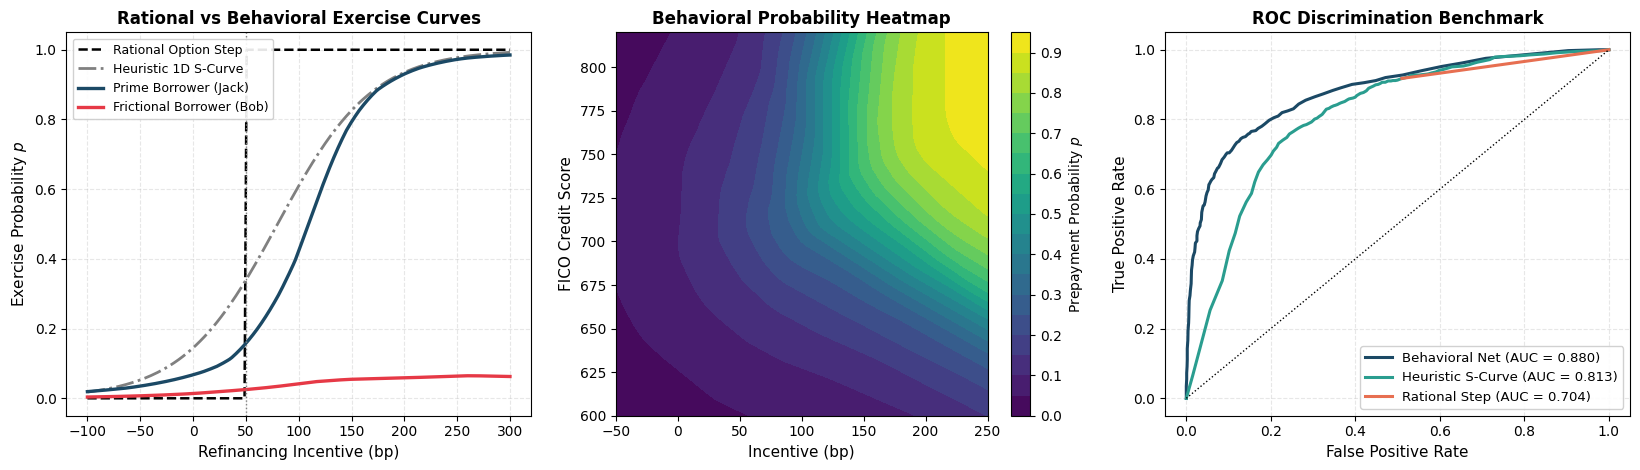

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

# Panel 1: Persona Exercise Curves
ax1 = axes[0]
ax1.plot(incentives, p_rational, "k--", lw=1.8, label="Rational Option Step")
ax1.plot(incentives, p_heuristic, color="gray", ls="-.", lw=2.0, label="Heuristic 1D S-Curve")
ax1.plot(incentives, p_prime, color="#1b4965", lw=2.4, label="Prime Borrower (Jack)")
ax1.plot(incentives, p_frictional, color="#e63946", lw=2.4, label="Frictional Borrower (Bob)")
ax1.axvline(50, color="gray", ls=":", lw=1.0)
ax1.set_xlabel("Refinancing Incentive (bp)", fontsize=11)
ax1.set_ylabel("Exercise Probability $p$", fontsize=11)
ax1.set_title("Rational vs Behavioral Exercise Curves", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, ls="--")
ax1.legend(loc="upper left", framealpha=0.9, fontsize=9)

# Panel 2: 2D Heatmap (Incentive vs FICO)
inc_mesh = np.linspace(-50, 250, 60)
fico_mesh = np.linspace(600, 820, 60)
INC, FICO = np.meshgrid(inc_mesh, fico_mesh)
grid_flat = np.column_stack([
    INC.flatten(),
    FICO.flatten(),
    np.full(INC.size, 72.0),
    np.full(INC.size, 300000.0),
    np.full(INC.size, 0.0),
])
grid_norm = torch.tensor((grid_flat - mean) / std, dtype=torch.float32)
with torch.no_grad():
    Z = model(grid_norm).numpy().reshape(INC.shape)

ax2 = axes[1]
c = ax2.contourf(INC, FICO, Z, levels=20, cmap="viridis")
cbar = fig.colorbar(c, ax=ax2)
cbar.set_label("Prepayment Probability $p$", fontsize=10)
ax2.set_xlabel("Incentive (bp)", fontsize=11)
ax2.set_ylabel("FICO Credit Score", fontsize=11)
ax2.set_title("Behavioral Probability Heatmap", fontsize=12, fontweight="bold")

# Panel 3: ROC Benchmark on Out-of-Sample Cohort
ax3 = axes[2]
X_eval, y_eval, _ = generate_cohort(n_samples=3000, seed=999)
X_eval_norm = torch.tensor((X_eval - mean) / std, dtype=torch.float32)
with torch.no_grad():
    score_nn_eval = model(X_eval_norm).numpy()
score_heu_eval = 1.0 / (1.0 + np.exp(-(X_eval[:, 0] - 80.0) / 45.0))
score_rat_eval = (X_eval[:, 0] >= 50.0).astype(float)

auc_nn_val = roc_auc_score(y_eval, score_nn_eval)
auc_heu_val = roc_auc_score(y_eval, score_heu_eval)
auc_rat_val = roc_auc_score(y_eval, score_rat_eval)

for sc, lbl, col in [
    (score_nn_eval, f"Behavioral Net (AUC = {auc_nn_val:.3f})", "#1b4965"),
    (score_heu_eval, f"Heuristic S-Curve (AUC = {auc_heu_val:.3f})", "#2a9d8f"),
    (score_rat_eval, f"Rational Step (AUC = {auc_rat_val:.3f})", "#e76f51"),
]:
    thresholds = np.linspace(0, 1, 100)
    tpr, fpr = [], []
    for th in thresholds:
        yp = (sc >= th).astype(int)
        tp = np.sum((yp == 1) & (y_eval == 1))
        fp = np.sum((yp == 1) & (y_eval == 0))
        fn = np.sum((yp == 0) & (y_eval == 1))
        tn = np.sum((yp == 0) & (y_eval == 0))
        tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    ax3.plot(fpr, tpr, color=col, lw=2.2, label=lbl)

ax3.plot([0, 1], [0, 1], "k:", lw=1.0)
ax3.set_xlabel("False Positive Rate", fontsize=11)
ax3.set_ylabel("True Positive Rate", fontsize=11)
ax3.set_title("ROC Discrimination Benchmark", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3, ls="--")
ax3.legend(loc="lower right", framealpha=0.9, fontsize=9.5)

plt.tight_layout()
plt.show()


## Key Financial & Machine Learning Takeaways

1. **Failure of the Rational Option Boundary**: Real mortgage borrowers do not follow the sharp exercise boundary of American financial options. Credit gates, loan balances, and behavioral burnout produce vast heterogeneity in exercise probability across borrowers facing the exact same interest rate incentive.
2. **Beyond One-Factor S-Curves**: Classical 1D heuristic S-curves treat all loans with +150 bp incentive identically. The Behavioral Neural Network uncovers the underlying gating mechanisms, lifting test-set ROC-AUC from $0.818$ to $0.868$ (+0.05). At +150 bp it puts prime Jack at about 79% and constrained Bob at about 5%, where the S-curve gives both the same 82%.
3. **Desk Application & Competing Risks**: In trading desk production (as detailed in Chapters 7 and 9), this behavioral classifier serves as the foundation for multi-state transition matrices (prepay, default, or active) and hybrid residual modeling.
